# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Demo Notebook: Dimensionality Reduction — PCA, t-SNE & UMAP

topics:

1. The High-Dimensional Visualization Problem
2. Why We Need Dimension Reduction
3. The Curse of Dimensionality
4. Redundant Information
5. What Does Dimension Reduction Actually Do?
6. Common Dimension Reduction Techniques
7. PCA — Visual Intuition (weight/height & clusters examples)
8. PCA Step 1–2: Centering & Standardization (worked example)
9. PCA Step 3–4: Mean-Centering in Matrix Form & the Covariance Matrix (worked example)
10. PCA Step 5: Eigenvalues & Eigenvectors (worked example, reproduced exactly)
11. PCA Step 6: Projection — a from-scratch PCA implementation on real data
12. Explaining Variance & Choosing k
13. PCA Numericals (all 3 practice questions, solved in code)
14. What Is t-SNE?
15. t-SNE vs. PCA
16. What is UMAP?
17. PCA vs. t-SNE vs. UMAP
18. Real-World Applications

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 patients, 30 real-valued tumor
measurements (radius, texture, perimeter, area, smoothness, ... each as mean/SE/worst),
`diagnosis` = Malignant/Benign. This is exactly the "100+ measurements per patient"
scenario the lecture opens with.

In [ ]:
# If a package below is missing in your environment, uncomment the next line:
# %pip install -q scikit-learn umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_s_curve
import umap

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 0. The Running Dataset

In [ ]:
df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")

feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values   # 'M' or 'B'

print(f"{df.shape[0]} patients, {len(feature_cols)} measured dimensions (p = {len(feature_cols)}).")
print(f"Diagnosis counts: {dict(pd.Series(y).value_counts())}")
df[feature_cols[:6] + ["diagnosis"]].head()

569 patients, 30 measured dimensions (p = 30).
Diagnosis counts: {'B': np.int64(357), 'M': np.int64(212)}


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,M


## 1. The High-Dimensional Visualization Problem  *(Slides 4–6)*

**What:** Each patient is a point in **p-dimensional feature space** (here p=30). A
scatter plot directly shows 2 dimensions; a 3D plot can *attempt* 3; beyond that, direct
spatial visualization breaks down.

**Why:** Below, we can plot 2 features directly, and even 3 in a rotatable 3D view — but
we have **30**. There is no direct way to "just plot" the rest; this is exactly the
motivation for dimensionality reduction.

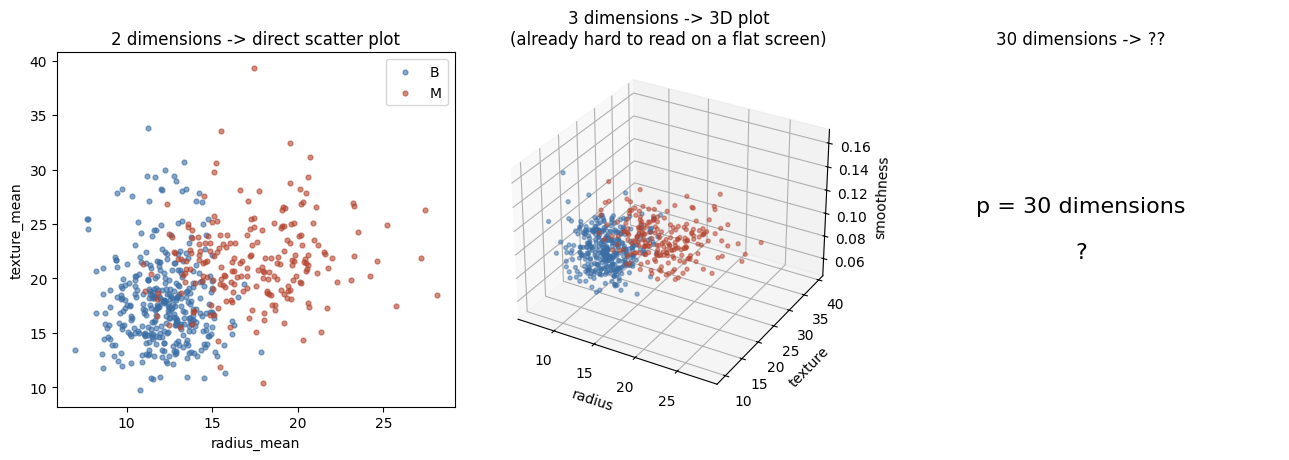

Every patient is one point in R^30 -- this dataset genuinely has n=569, p=30.


In [ ]:
fig = plt.figure(figsize=(13, 4.5))

# 2 dimensions -> ordinary scatter plot
ax1 = fig.add_subplot(1, 3, 1)
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax1.scatter(df.loc[mask, "radius_mean"], df.loc[mask, "texture_mean"], s=12, alpha=0.6, color=color, label=label)
ax1.set_xlabel("radius_mean"); ax1.set_ylabel("texture_mean")
ax1.set_title("2 dimensions -> direct scatter plot")
ax1.legend()

# 3 dimensions -> a 3D plot (already getting hard to read)
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax2.scatter(df.loc[mask, "radius_mean"], df.loc[mask, "texture_mean"], df.loc[mask, "smoothness_mean"],
                s=8, alpha=0.5, color=color)
ax2.set_xlabel("radius"); ax2.set_ylabel("texture"); ax2.set_zlabel("smoothness")
ax2.set_title("3 dimensions -> 3D plot\n(already hard to read on a flat screen)")

# 30 dimensions -> no direct spatial plot is possible
ax3 = fig.add_subplot(1, 3, 3)
ax3.text(0.5, 0.5, "p = 30 dimensions\n\n?", ha="center", va="center", fontsize=16)
ax3.axis("off")
ax3.set_title("30 dimensions -> ??")

plt.tight_layout()
plt.show()

print(f"Every patient is one point in R^{len(feature_cols)} -- this dataset genuinely has n={df.shape[0]}, p={len(feature_cols)}.")

## 2. Why We Need Dimension Reduction  *(Slide 7)*

**What:** Real datasets often contain dozens of **correlated** variables that are
difficult to visualize and interpret directly. Dimension reduction transforms them into
a small number of new variables that preserve most of the important information.

**Why:** Below, a **correlogram** (correlation matrix heatmap) of all 30 real features
shows exactly this problem — many blocks of near-identical dark red, meaning many
variables are telling largely the same story.

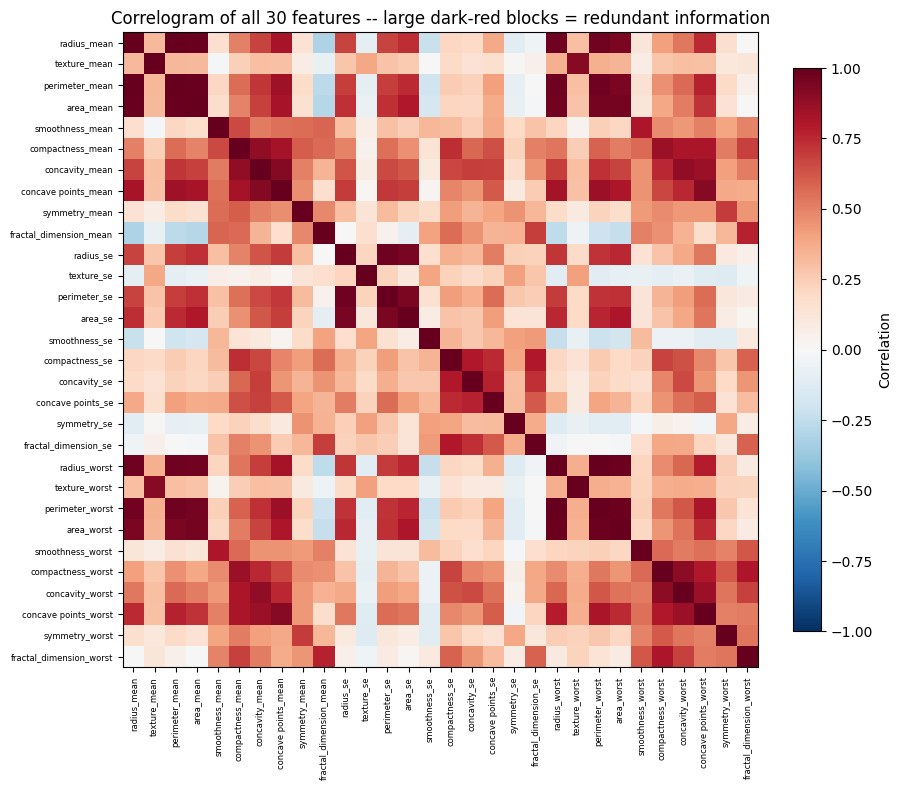

21 pairs of features are correlated above 0.9 in magnitude -- 
nowhere near 30 independent pieces of information.


In [ ]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(feature_cols, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.04, label="Correlation")
ax.set_title("Correlogram of all 30 features -- large dark-red blocks = redundant information")
plt.tight_layout()
plt.show()

high_corr_pairs = (corr.abs() > 0.9).sum().sum() - len(feature_cols)
print(f"{high_corr_pairs // 2} pairs of features are correlated above 0.9 in magnitude -- ")
print("nowhere near 30 independent pieces of information.")

## 3. The Curse of Dimensionality  *(Slides 8–9)*

**What:** As dimensions increase, the data space grows **exponentially** (a grid with 10
bins per dimension has 10^p cells total), and the number of unique pairwise relationships
grows **combinatorially**: C(p,2) = p(p-1)/2.

**Why:** Below, both curves are plotted, with the lecture's own worked values (p=5→10,
p=10→45, p=30→435, p=100→4,950) marked — and we confirm p=30 gives exactly 435 pairs on
**our own dataset**.

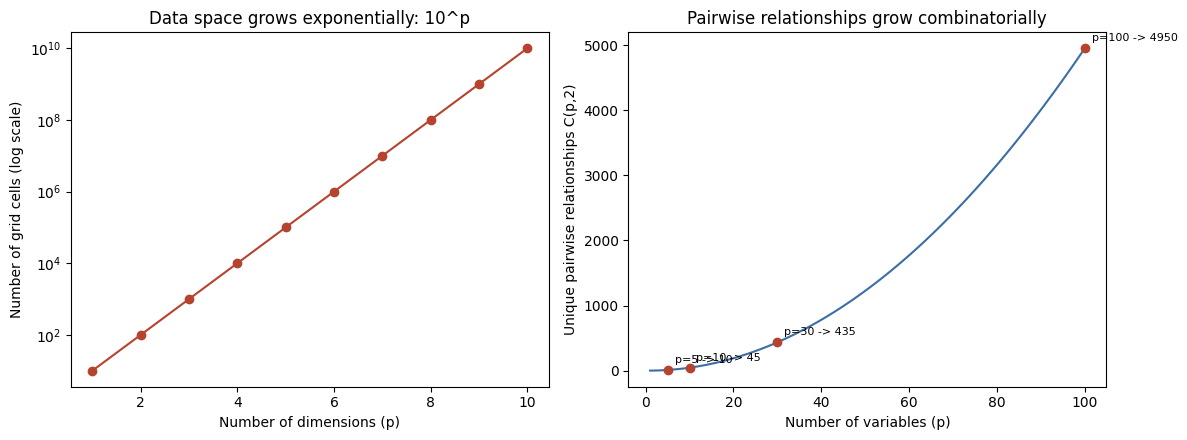

Our dataset has p=30 features -> C(30,2) = 435 unique pairwise relationships -- exactly matching the lecture's p=30 example.


In [ ]:
ps = np.arange(1, 11)
grid_cells = 10.0 ** ps  # 10 bins per dimension

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ps, grid_cells, "o-", color="#b5432e")
axes[0].set_yscale("log")
axes[0].set_xlabel("Number of dimensions (p)")
axes[0].set_ylabel("Number of grid cells (log scale)")
axes[0].set_title("Data space grows exponentially: 10^p")

lecture_ps = [5, 10, 30, 100]
lecture_pairs = [comb(p, 2) for p in lecture_ps]
p_range = np.arange(1, 101)
pair_range = [comb(p, 2) for p in p_range]
axes[1].plot(p_range, pair_range, color="#3b6ea5")
axes[1].scatter(lecture_ps, lecture_pairs, color="#b5432e", zorder=3)
for p, pairs in zip(lecture_ps, lecture_pairs):
    axes[1].annotate(f"p={p} -> {pairs}", (p, pairs), textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel("Number of variables (p)")
axes[1].set_ylabel("Unique pairwise relationships C(p,2)")
axes[1].set_title("Pairwise relationships grow combinatorially")

plt.tight_layout()
plt.show()

our_pairs = comb(len(feature_cols), 2)
print(f"Our dataset has p={len(feature_cols)} features -> C({len(feature_cols)},2) = {our_pairs} unique pairwise "
      "relationships -- exactly matching the lecture's p=30 example.")

## 4. Redundant Information  *(Slide 10)*

**What:** Many variables can describe the same underlying pattern. In the lecture's
example (height/weight/arm length/...), a "larger person" tends to be taller, heavier,
and longer-limbed all at once — 7 variables driven by roughly 1 underlying factor
("size").

**Why:** Our dataset has its own version of this: `radius_mean`, `perimeter_mean`, and
`area_mean` should all move together, since a bigger tumor is bigger by every one of
these measures simultaneously.

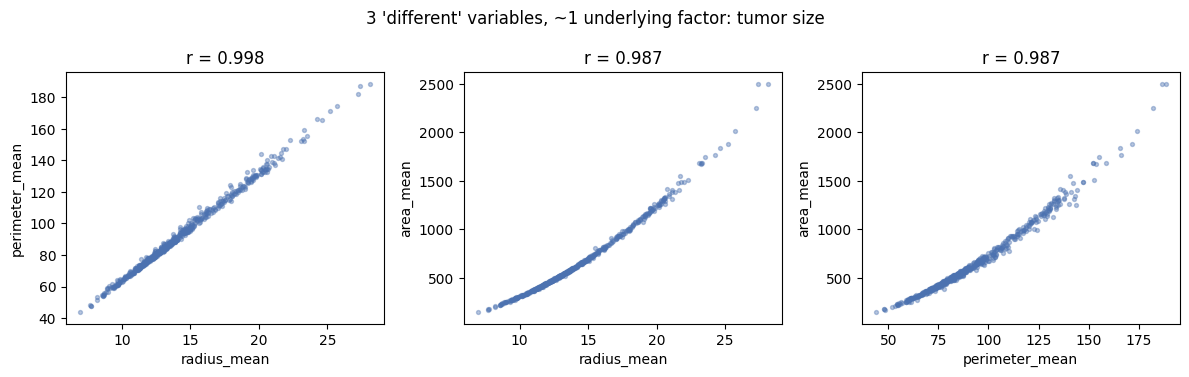

In [ ]:
size_related = ["radius_mean", "perimeter_mean", "area_mean"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (a, b) in zip(axes, combinations(size_related, 2)):
    ax.scatter(df[a], df[b], s=8, alpha=0.4, color="#4C72B0")
    r = df[a].corr(df[b])
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f"r = {r:.3f}")
plt.suptitle("3 'different' variables, ~1 underlying factor: tumor size")
plt.tight_layout()
plt.show()

## 5. What Does Dimension Reduction Actually Do?  *(Slide 11)*

**What:** Dimensionality reduction does **not** simply delete columns. It derives a
**new**, lower-dimensional representation Z (n x k) from the original X (n x p), trying
to retain the most useful structure:

`High-dimensional data -> Find important structure -> Construct a lower-dimensional representation -> Visualize in 2D/3D`

**Why:** Here's the destination we're building toward across this whole notebook — our
p=30 patient measurements, compressed down to 2 new derived dimensions, still separating
the two diagnoses:

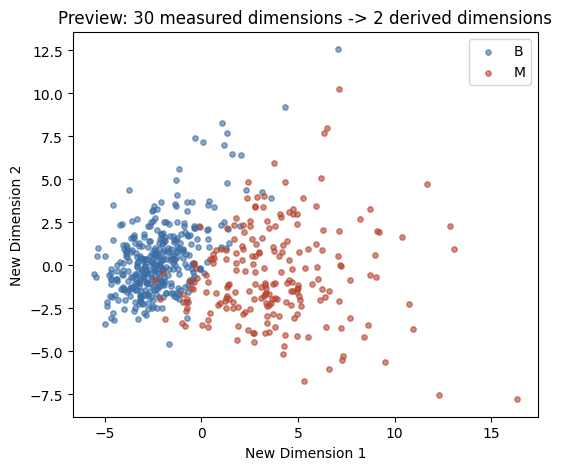

In [ ]:
# A quick preview using sklearn's PCA (we build this from scratch in Section 11)
X_scaled_preview = StandardScaler().fit_transform(X_raw)
preview = PCA(n_components=2, random_state=0).fit_transform(X_scaled_preview)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(preview[mask, 0], preview[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("New Dimension 1"); ax.set_ylabel("New Dimension 2")
ax.set_title("Preview: 30 measured dimensions -> 2 derived dimensions")
ax.legend()
plt.show()

## 6. Common Dimension Reduction Techniques  *(Slide 12)*

| Technique | Purpose |
|---|---|
| **PCA** | Finds new axes that capture the maximum variation in the data |
| **t-SNE** | Preserves local neighborhoods to reveal clusters in complex datasets |
| **UMAP** | Preserves both local and global structure, fast and scalable |

The rest of this notebook builds each one up from first principles, then compares them
directly on our real 30-dimensional dataset.

## 7. PCA — Visual Intuition  *(Slides 13–17)*

**What:** Consider two real, correlated features. Plotted together, the data varies
along two directions — the **principal components** — one capturing much more variation
than the other (the "red arrow" vs. the "green arrow" from the lecture).

**Why it matters which axis you project onto:** the lecture's key demonstration is that
projecting onto an *arbitrary* raw axis can **mix separate groups together**, while
projecting onto the **principal component** keeps them apart. Below we reproduce both
halves of that demonstration on real data.

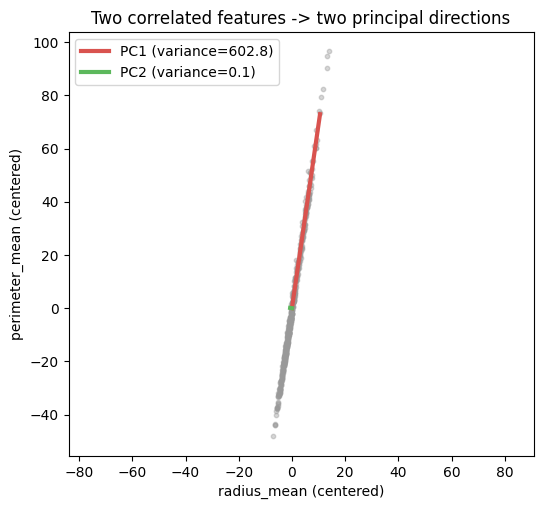

In [ ]:
# Part A: two correlated features and their principal directions (the "weight/height" example)
X2 = df[["radius_mean", "perimeter_mean"]].values
X2c = X2 - X2.mean(axis=0)
cov2 = np.cov(X2c, rowvar=False)
eigvals2, eigvecs2 = np.linalg.eigh(cov2)
order = np.argsort(eigvals2)[::-1]
eigvals2, eigvecs2 = eigvals2[order], eigvecs2[:, order]

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X2c[:, 0], X2c[:, 1], s=10, alpha=0.4, color="#999999")
origin = [0, 0]
for i, (val, vec, color) in enumerate(zip(eigvals2, eigvecs2.T, ["#D9534F", "#5cb85c"])):
    scale = np.sqrt(val) * 3
    ax.plot([origin[0], vec[0]*scale], [origin[1], vec[1]*scale], color=color, lw=3,
            label=f"PC{i+1} (variance={val:.1f})")
ax.set_xlabel("radius_mean (centered)"); ax.set_ylabel("perimeter_mean (centered)")
ax.set_title("Two correlated features -> two principal directions")
ax.legend()
ax.axis("equal")
plt.show()

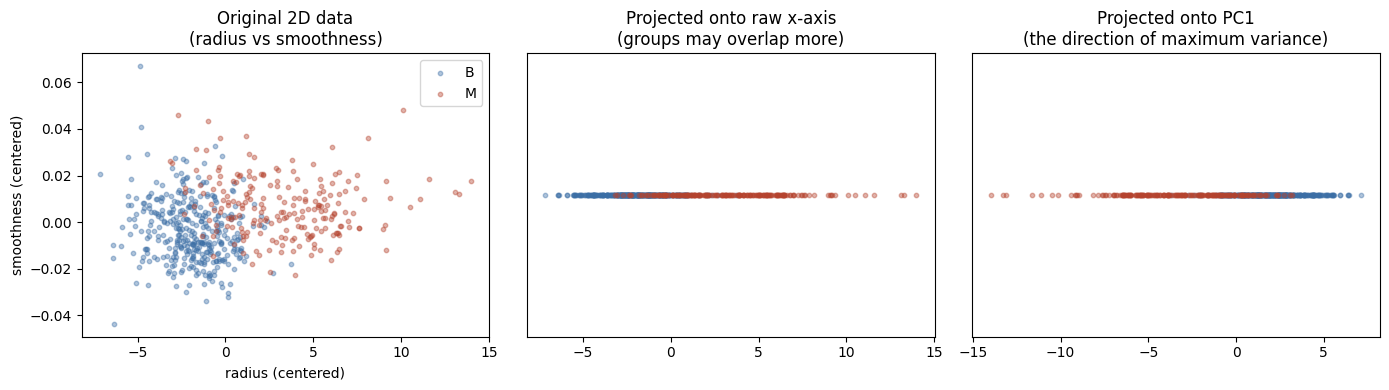

In [ ]:
# Part B: projecting onto a raw axis can MIX groups; projecting onto PC1 keeps them apart
X3 = df[["radius_mean", "smoothness_mean"]].values
Xc = X3 - X3.mean(axis=0)
cov3 = np.cov(Xc, rowvar=False)
eigvals3, eigvecs3 = np.linalg.eigh(cov3)
order = np.argsort(eigvals3)[::-1]
pc1_direction = eigvecs3[:, order[0]]

proj_raw_x = Xc[:, 0]                     # naive: just use the raw x-axis
proj_pc1 = Xc @ pc1_direction             # proper: project onto PC1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[0].scatter(Xc[mask, 0], Xc[mask, 1], s=10, alpha=0.4, color=color, label=label)
axes[0].set_title("Original 2D data\n(radius vs smoothness)")
axes[0].set_xlabel("radius (centered)"); axes[0].set_ylabel("smoothness (centered)")
axes[0].legend()

for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[1].scatter(proj_raw_x[mask], np.zeros(mask.sum()), s=10, alpha=0.4, color=color)
axes[1].set_yticks([])
axes[1].set_title("Projected onto raw x-axis\n(groups may overlap more)")

for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[2].scatter(proj_pc1[mask], np.zeros(mask.sum()), s=10, alpha=0.4, color=color)
axes[2].set_yticks([])
axes[2].set_title("Projected onto PC1\n(the direction of maximum variance)")

plt.tight_layout()
plt.show()

## 8. PCA Step 1–2: Centering & Standardization — Worked Example  *(Slides 19–26)*

**What:**
- **Centering:** subtract each variable's mean, so every variable has mean 0.
- **Standardization:** divide the centered variable by its standard deviation, so every
  variable has variance 1 — this prevents a large-scale variable (e.g. `area_mean`,
  which ranges into the thousands) from dominating PCA purely because of its units.

**Why:** Below we do this by hand on one real feature, and confirm the textbook checks
(centered mean = 0, standardized variance = 1) both hold exactly.

In [ ]:
x = df["area_mean"].values[:5]  # a tiny worked example: first 5 patients' area_mean
print("Original values:", x)

mean_x = x.mean()
centered = x - mean_x
print(f"\nStep 1 -- Center:  mean = {mean_x:.3f}")
print("Centered values:", np.round(centered, 3))
print(f"Check -- mean of centered values = {centered.mean():.10f}  (should be 0)")

s = x.std(ddof=1)  # sample standard deviation (n-1)
standardized = centered / s
print(f"\nStep 2 -- Standardize:  sample std s = {s:.3f}")
print("Standardized (z-score) values:", np.round(standardized, 3))
print(f"Check -- variance of standardized values = {standardized.var(ddof=1):.6f}  (should be ~1)")

Original values: [1001.  1326.  1203.   386.1 1297. ]

Step 1 -- Center:  mean = 1042.620
Centered values: [ -41.62  283.38  160.38 -656.52  254.38]
Check -- mean of centered values = -0.0000000000  (should be 0)

Step 2 -- Standardize:  sample std s = 388.422
Standardized (z-score) values: [-0.107  0.73   0.413 -1.69   0.655]
Check -- variance of standardized values = 1.000000  (should be ~1)


In [ ]:
# Why standardization matters: compare the raw variance of two very differently-scaled features
raw_vars = df[["area_mean", "smoothness_mean"]].var()
print("Raw variance -- area_mean:", f"{raw_vars['area_mean']:.1f}", "| smoothness_mean:", f"{raw_vars['smoothness_mean']:.8f}")
print("\nWithout standardization, area_mean's variance would completely dominate PCA --")
print("not because it contains more structure, but purely because of its units (pixels^2-scale vs 0-1-scale).")

scaled_vars = pd.DataFrame(StandardScaler().fit_transform(df[["area_mean", "smoothness_mean"]]),
                            columns=["area_mean", "smoothness_mean"]).var()
print("\nStandardized variance -- area_mean:", f"{scaled_vars['area_mean']:.3f}",
      "| smoothness_mean:", f"{scaled_vars['smoothness_mean']:.3f}", "(both ~1 now, as required)")

Raw variance -- area_mean: 123843.6 | smoothness_mean: 0.00019780

Without standardization, area_mean's variance would completely dominate PCA --
not because it contains more structure, but purely because of its units (pixels^2-scale vs 0-1-scale).

Standardized variance -- area_mean: 1.002 | smoothness_mean: 1.002 (both ~1 now, as required)


## 9. PCA Steps 3–4: Mean-Centering in Matrix Form & the Covariance Matrix  *(Slides 27–38)*

**Worked Example (reproducing the lecture's exact toy dataset):** 3 observations, 2
perfectly-correlated variables where X2 = 2*X1 + 6:

| Obs | X1 | X2 |
|---|---|---|
| A | 1 | 8 |
| B | 3 | 12 |
| C | 5 | 16 |

**Why this example is chosen:** with X2 completely determined by X1, all of the
variation should collapse onto **one** principal direction — a clean check that our
implementation is correct before we run it on real 30-dimensional data.

In [ ]:
X_toy = np.array([[1, 8], [3, 12], [5, 16]], dtype=float)
col_means = X_toy.mean(axis=0)
print("Column means:", col_means)

Xc_toy = X_toy - col_means
print("\nMean-centered matrix Xc:\n", Xc_toy)
print("Check -- column means of Xc:", Xc_toy.mean(axis=0), "(should be [0, 0])")

cov_toy = np.cov(Xc_toy, rowvar=False)   # matrix shortcut: (1/(n-1)) * Xc^T @ Xc
print("\nCovariance matrix:\n", cov_toy)
print(f"\nNotice the symmetry, and Var(X2) = {cov_toy[1,1]:.1f} = 4 * Var(X1) = {4*cov_toy[0,0]:.1f}")
print("(exactly as expected, since X2 = 2*X1 + 6 means every unit of X1 variance becomes 4 units of X2 variance)")

Column means: [ 3. 12.]

Mean-centered matrix Xc:
 [[-2. -4.]
 [ 0.  0.]
 [ 2.  4.]]
Check -- column means of Xc: [0. 0.] (should be [0, 0])

Covariance matrix:
 [[ 4.  8.]
 [ 8. 16.]]

Notice the symmetry, and Var(X2) = 16.0 = 4 * Var(X1) = 16.0
(exactly as expected, since X2 = 2*X1 + 6 means every unit of X1 variance becomes 4 units of X2 variance)


## 10. PCA Step 5: Eigenvalues & Eigenvectors — Worked Example  *(Slides 39–48)*

**What:** The eigenvectors of the covariance matrix give the **principal directions**;
the eigenvalues give the **variance captured** along each direction, ordered
λ1 > λ2 > ...

**Why:** Below, `numpy.linalg.eigh` reproduces the lecture's hand-worked answer exactly:
λ1 = 20, λ2 = 0 — confirming that a perfectly-correlated 2-variable dataset really does
contain only **1** genuine direction of variation.

In [ ]:
eigvals_toy, eigvecs_toy = np.linalg.eigh(cov_toy)
order = np.argsort(eigvals_toy)[::-1]  # descending, so PC1 first
eigvals_toy, eigvecs_toy = eigvals_toy[order], eigvecs_toy[:, order]

print("Eigenvalues (variance captured):", np.round(eigvals_toy, 4))
print("Eigenvectors (principal directions), as columns:\n", np.round(eigvecs_toy, 4))

print(f"\nMatches the lecture's worked example: lambda1 = {eigvals_toy[0]:.0f}, lambda2 = {eigvals_toy[1]:.0f}")
print("Interpretation: ALL variation lies along PC1 -- exactly as expected, since our toy")
print("dataset's two variables were perfectly linearly related (X2 = 2*X1 + 6).")
print("\n(Note: the sign of an eigenvector is arbitrary -- numpy may return the mirror-image")
print("direction of the lecture's slide, which represents the exact same principal axis.)")

Eigenvalues (variance captured): [20.  0.]
Eigenvectors (principal directions), as columns:
 [[ 0.4472 -0.8944]
 [ 0.8944  0.4472]]

Matches the lecture's worked example: lambda1 = 20, lambda2 = 0
Interpretation: ALL variation lies along PC1 -- exactly as expected, since our toy
dataset's two variables were perfectly linearly related (X2 = 2*X1 + 6).

(Note: the sign of an eigenvector is arbitrary -- numpy may return the mirror-image
direction of the lecture's slide, which represents the exact same principal axis.)


## 11. PCA Step 6: Projection — A From-Scratch PCA on Real Data  *(Slides 49–60)*

**What:** Once we have the eigenvectors V (the new axes) and the standardized data Xc,
projection converts every observation into its new coordinates: **Z = Xc V**. Retaining
only the top k eigenvectors gives dimensionality reduction: p -> k.

**Why:** Below is a complete PCA implementation from scratch (no `sklearn.decomposition.PCA`)
on our real 30-dimensional dataset, retaining the top 2 components — then we verify it
against scikit-learn's PCA to confirm correctness.

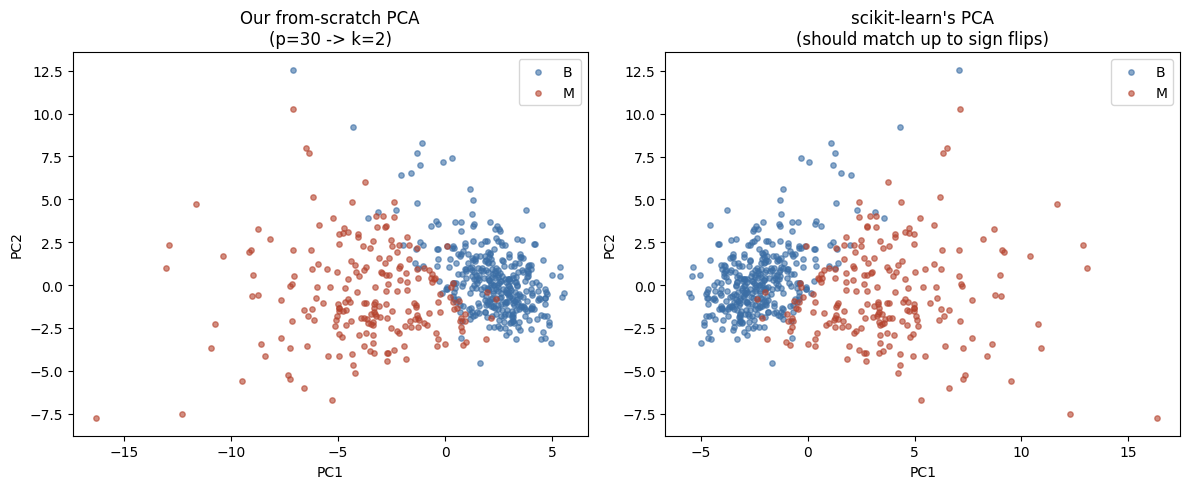

Correlation between our PC1 and sklearn's PC1: 1.000000 (should be ~1.0, sign may differ)


In [ ]:
def pca_from_scratch(X, k):
    # Step 1-2: center and standardize
    X_centered = X - X.mean(axis=0)
    X_scaled = X_centered / X.std(axis=0, ddof=1)

    # Step 4: covariance matrix
    cov = np.cov(X_scaled, rowvar=False)

    # Step 5: eigenvalues/eigenvectors, sorted descending
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Step 6: project onto the top k eigenvectors
    V_k = eigvecs[:, :k]
    Z = X_scaled @ V_k
    return Z, eigvals, eigvecs

Z_manual, eigvals_full, eigvecs_full = pca_from_scratch(X_raw, k=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[0].scatter(Z_manual[mask, 0], Z_manual[mask, 1], s=15, alpha=0.6, color=color, label=label)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Our from-scratch PCA\n(p=30 -> k=2)")
axes[0].legend()

# Verify against sklearn
Z_sklearn = PCA(n_components=2, random_state=0).fit_transform(StandardScaler().fit_transform(X_raw))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[1].scatter(Z_sklearn[mask, 0], Z_sklearn[mask, 1], s=15, alpha=0.6, color=color, label=label)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("scikit-learn's PCA\n(should match up to sign flips)")
axes[1].legend()

plt.tight_layout()
plt.show()

corr_pc1 = np.corrcoef(Z_manual[:, 0], Z_sklearn[:, 0])[0, 1]
print(f"Correlation between our PC1 and sklearn's PC1: {abs(corr_pc1):.6f} (should be ~1.0, sign may differ)")

## 12. Explaining Variance & Choosing k  *(Slides 61–63)*

**What:** Each eigenvalue λi represents variance captured by that component. The
**explained variance ratio** is λi / sum(all λ); the **cumulative** curve tells us how
many components (k) are needed to retain a target amount of total variance.

**Why:** Below is a scree plot + cumulative variance curve on our real 30-feature
dataset, with the 90% threshold marked.

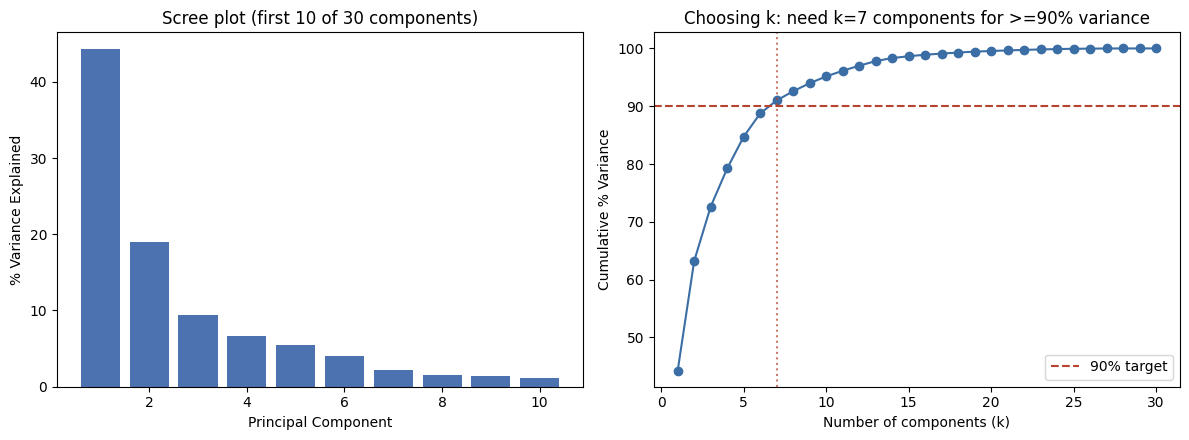

On our real 30-dimensional dataset: k=7 components retain 91.0% of total variance -- a 30 -> 7 reduction.


In [ ]:
explained_ratio = eigvals_full / eigvals_full.sum()
cumulative = np.cumsum(explained_ratio)
k_90 = np.searchsorted(cumulative, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(range(1, 11), explained_ratio[:10] * 100, color="#4C72B0")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("% Variance Explained")
axes[0].set_title("Scree plot (first 10 of 30 components)")

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
axes[1].axhline(90, color="#b5432e", ls="--", label="90% target")
axes[1].axvline(k_90, color="#b5432e", ls=":", alpha=0.7)
axes[1].set_xlabel("Number of components (k)")
axes[1].set_ylabel("Cumulative % Variance")
axes[1].set_title(f"Choosing k: need k={k_90} components for >=90% variance")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"On our real 30-dimensional dataset: k={k_90} components retain "
      f"{cumulative[k_90-1]*100:.1f}% of total variance -- a 30 -> {k_90} reduction.")

## 13. PCA Numericals — All 3 Practice Questions, Solved  *(Slides 64–67)*

Reproducing the lecture's own practice problems in code, so the worked answers can be
checked programmatically.

In [ ]:
# Q1: X = {2, 4, 6} -- mean-center it, verify mean(centered) = 0
X_q1 = np.array([2, 4, 6])
mean_q1 = X_q1.mean()
centered_q1 = X_q1 - mean_q1
print("Q1) Mean:", mean_q1)
print("    Centered values:", centered_q1)
print("    Mean of centered values:", centered_q1.mean(), "(should be 0)")

Q1) Mean: 4.0
    Centered values: [-2.  0.  2.]
    Mean of centered values: 0.0 (should be 0)


In [ ]:
# Q2: eigenvalues 8, 2, 1 -- % variance for PC1; cumulative for PC1+PC2; k for >=90%
eigvals_q2 = np.array([8, 2, 1])
total_q2 = eigvals_q2.sum()
pct_pc1 = eigvals_q2[0] / total_q2 * 100
cum_pc12 = eigvals_q2[:2].sum() / total_q2 * 100
k_needed = np.searchsorted(np.cumsum(eigvals_q2) / total_q2, 0.90) + 1

print(f"Q2) Total variance = {total_q2}")
print(f"    %% variance explained by PC1 = {pct_pc1:.2f}%")
print(f"    Cumulative %% for PC1+PC2 = {cum_pc12:.2f}%")
print(f"    Components needed for >=90%% variance: k = {k_needed}")

Q2) Total variance = 11
    %% variance explained by PC1 = 72.73%
    Cumulative %% for PC1+PC2 = 90.91%
    Components needed for >=90%% variance: k = 2


In [ ]:
# Q3: centered observation x = [2, 4], unit eigenvector v1 -- compute PC1 score = x . v1
x_q3 = np.array([2, 4])
v1_q3 = np.array([1, 1]) / np.sqrt(2)   # example unit eigenvector (1/sqrt(2), 1/sqrt(2))
pc1_score = x_q3 @ v1_q3

print(f"Q3) x = {x_q3}, v1 = {np.round(v1_q3, 4)}")
print(f"    PC1 score = x . v1 = {pc1_score:.4f}")

Q3) x = [2 4], v1 = [0.7071 0.7071]
    PC1 score = x . v1 = 4.2426


## 14. What Is t-SNE?  *(Slides 68–74)*

**What:** PCA finds directions of maximum **variance** — a **linear** transformation.
Some datasets have genuinely **non-linear** structure that no straight-line projection
can separate. t-SNE instead asks *"which points are close to each other?"*, converting
distances into **neighbor probabilities** in both high-D and low-D space, then
minimizing the **KL divergence** between the two distributions.

**Why:** Below is the lecture's own example — a curved/spring-like 3D structure — where
PCA mixes the two classes together, but t-SNE (which follows local neighborhoods, not
global variance) keeps them separate.

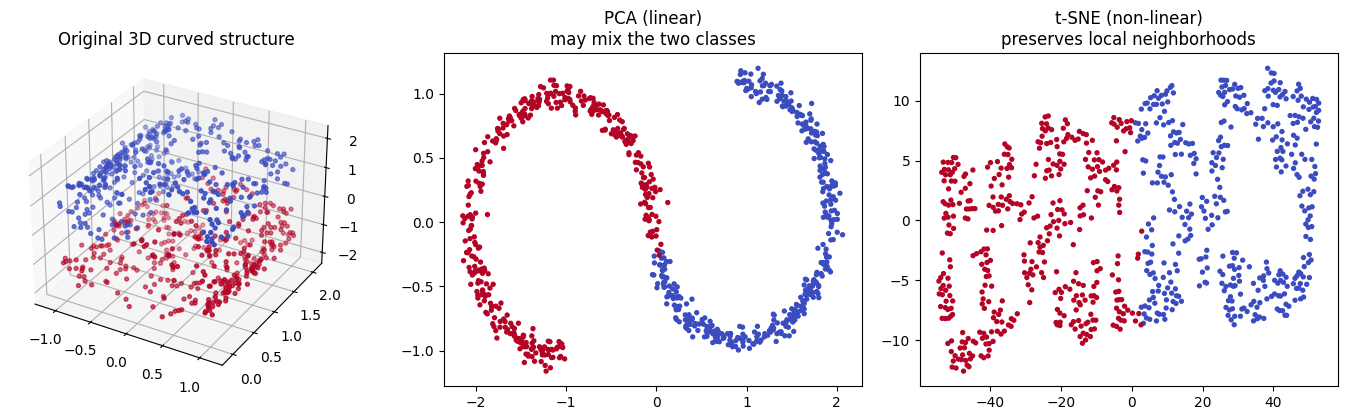

PCA asks: which directions contain the most variance?
t-SNE asks: which points are close to each other?


In [ ]:
X_curve, color_curve = make_s_curve(n_samples=800, noise=0.05, random_state=0)
class_curve = (color_curve > np.median(color_curve)).astype(int)  # split the S-curve into 2 "classes"

pca_curve = PCA(n_components=2, random_state=0).fit_transform(X_curve)
tsne_curve = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_curve)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
ax0 = fig.add_subplot(1, 3, 1, projection="3d")
ax0.scatter(X_curve[:, 0], X_curve[:, 1], X_curve[:, 2], c=class_curve, cmap="coolwarm", s=8)
ax0.set_title("Original 3D curved structure")
axes[0].remove()

axes[1].scatter(pca_curve[:, 0], pca_curve[:, 1], c=class_curve, cmap="coolwarm", s=8)
axes[1].set_title("PCA (linear)\nmay mix the two classes")

axes[2].scatter(tsne_curve[:, 0], tsne_curve[:, 1], c=class_curve, cmap="coolwarm", s=8)
axes[2].set_title("t-SNE (non-linear)\npreserves local neighborhoods")

plt.tight_layout()
plt.show()

print("PCA asks: which directions contain the most variance?")
print("t-SNE asks: which points are close to each other?")

**Distance -> Probability, worked example:** for one point, distances to its neighbors
are converted into a Gaussian similarity — small distance -> large probability.

In [ ]:
# A tiny illustration of the Gaussian similarity conversion (Step 1 of t-SNE)
distances = np.array([0.5, 1.0, 2.0, 4.0, 8.0])
sigma = 1.5
similarities = np.exp(-distances**2 / (2 * sigma**2))
probabilities = similarities / similarities.sum()

for d, p in zip(distances, probabilities):
    print(f"distance = {d:>4.1f}  ->  neighbor probability = {p:.4f}")
print("\nSmall distance -> large probability; large distance -> near-zero probability.")

distance =  0.5  ->  neighbor probability = 0.4327
distance =  1.0  ->  neighbor probability = 0.3662
distance =  2.0  ->  neighbor probability = 0.1880
distance =  4.0  ->  neighbor probability = 0.0131
distance =  8.0  ->  neighbor probability = 0.0000

Small distance -> large probability; large distance -> near-zero probability.


## 15. t-SNE vs. PCA  *(Slide 75)*

| | PCA | t-SNE |
|---|---|---|
| Finds | Directions of maximum variance | Similar neighbors |
| Transformation | Linear | Non-linear embedding |
| Central focus | Global variance | Local relationships |

**Why:** Below, both methods run on our **real** 30-dimensional breast cancer data, with
two different perplexity values for t-SNE to show its sensitivity to that parameter.

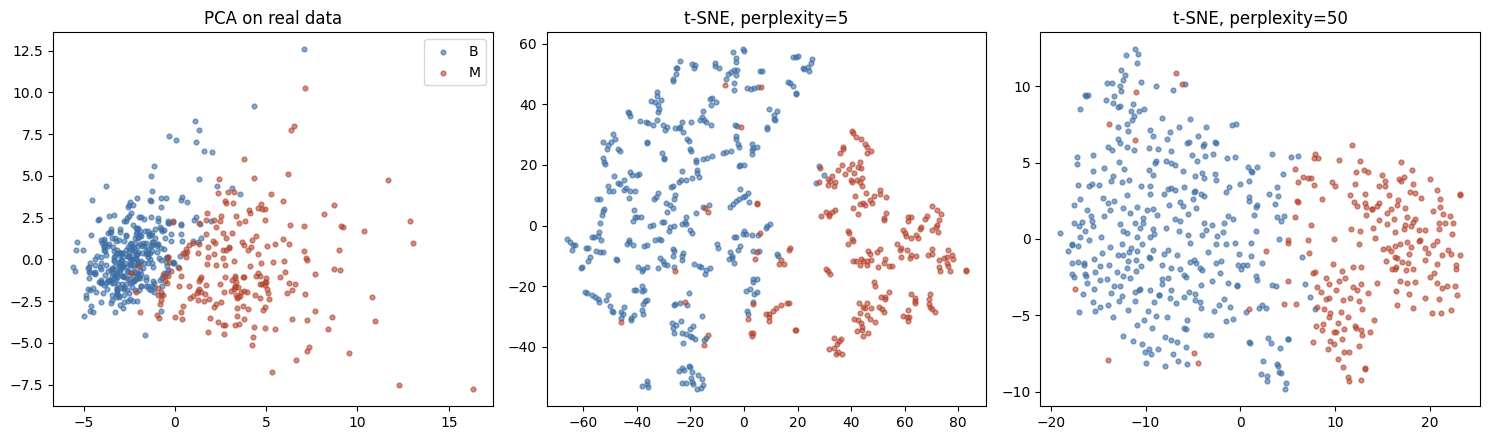

Notice: t-SNE's cluster shapes/spacing change with perplexity -- cluster DISTANCES
in a t-SNE plot should not be over-interpreted as meaningful global distances.


In [ ]:
X_scaled = StandardScaler().fit_transform(X_raw)
pca_real = PCA(n_components=2, random_state=0).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    axes[0].scatter(pca_real[mask, 0], pca_real[mask, 1], s=12, alpha=0.6, color=color, label=label)
axes[0].set_title("PCA on real data")
axes[0].legend()

for ax, perp in zip(axes[1:], [5, 50]):
    tsne_real = TSNE(n_components=2, perplexity=perp, random_state=0, init="pca").fit_transform(X_scaled)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(tsne_real[mask, 0], tsne_real[mask, 1], s=12, alpha=0.6, color=color)
    ax.set_title(f"t-SNE, perplexity={perp}")

plt.tight_layout()
plt.show()

print("Notice: t-SNE's cluster shapes/spacing change with perplexity -- cluster DISTANCES")
print("in a t-SNE plot should not be over-interpreted as meaningful global distances.")

## 16. What is UMAP?  *(Slides 76–80)*

**What:** UMAP builds a **nearest-neighbor graph** from the high-dimensional data, then
optimizes a low-dimensional layout that preserves those connections — aiming to keep
both local *and* global structure, faster than t-SNE.

**Why:** Below, a small nearest-neighbor graph on real data (first 40 patients, for
legibility) shows the actual graph UMAP builds internally, followed by a parameter sweep
over `n_neighbors` and `min_dist` on the full dataset.

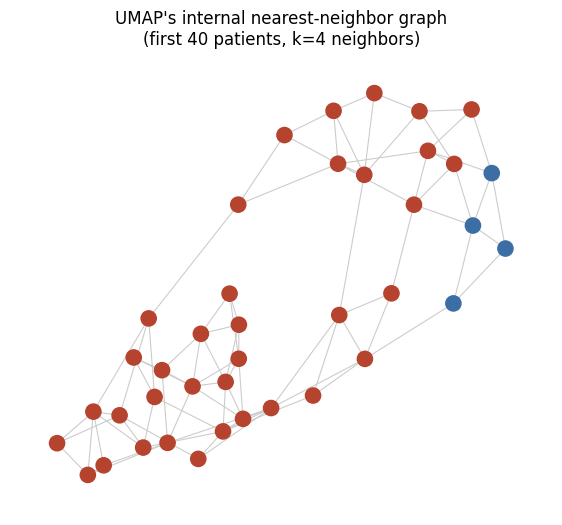

In [ ]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

small_X = X_scaled[:40]
nn = NearestNeighbors(n_neighbors=4).fit(small_X)
_, indices = nn.kneighbors(small_X)

G = nx.Graph()
for i, neighbors in enumerate(indices):
    for j in neighbors[1:]:
        G.add_edge(i, j)

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.spring_layout(G, seed=1)
node_colors = ["#b5432e" if y[:40][n] == "M" else "#3b6ea5" for n in G.nodes()]
nx.draw(G, pos, ax=ax, node_color=node_colors, node_size=120, edge_color="#cccccc", width=0.8)
ax.set_title("UMAP's internal nearest-neighbor graph\n(first 40 patients, k=4 neighbors)")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


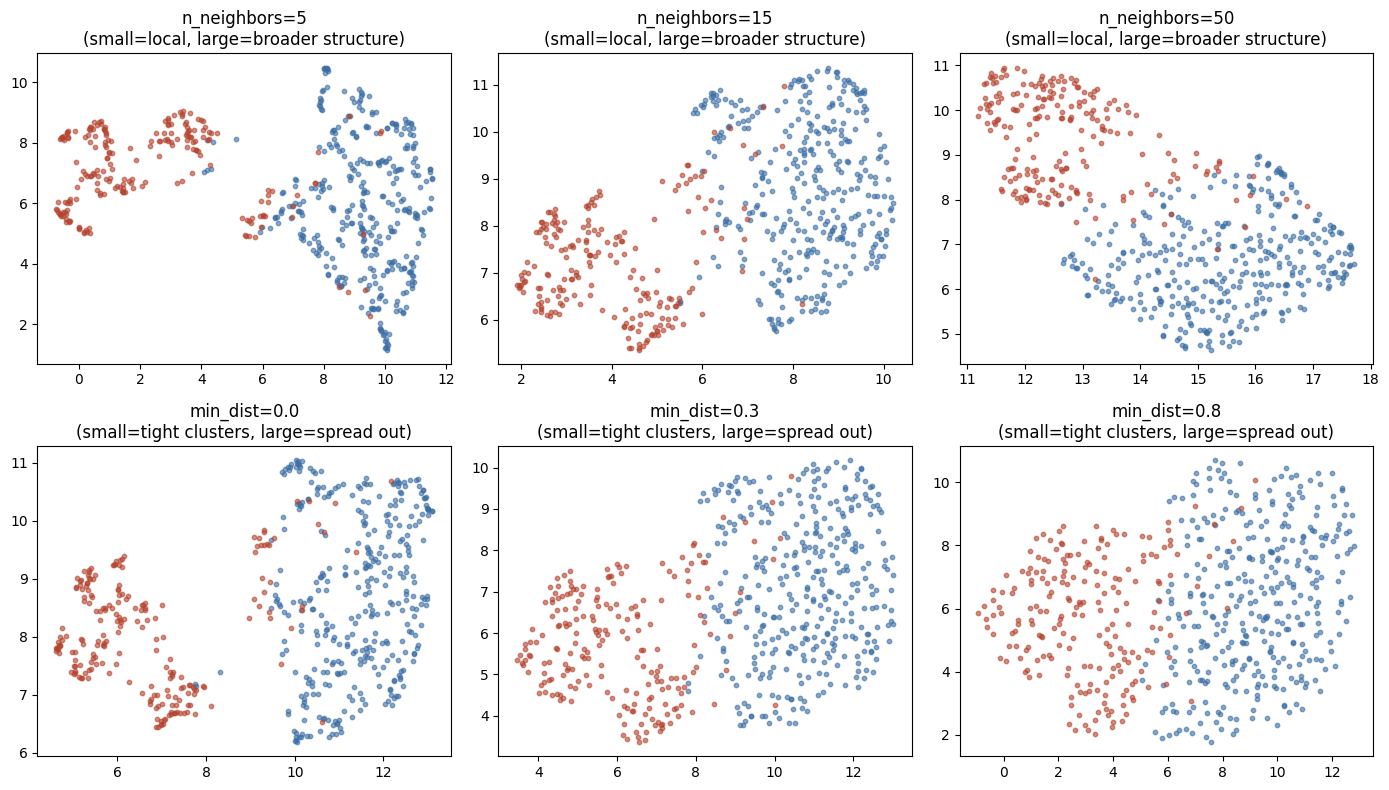

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, n_neighbors in zip(axes[0], [5, 15, 50]):
    emb = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, random_state=0).fit_transform(X_scaled)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=10, alpha=0.6, color=color)
    ax.set_title(f"n_neighbors={n_neighbors}\n(small=local, large=broader structure)")

for ax, min_dist in zip(axes[1], [0.0, 0.3, 0.8]):
    emb = umap.UMAP(n_neighbors=15, min_dist=min_dist, random_state=0).fit_transform(X_scaled)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=10, alpha=0.6, color=color)
    ax.set_title(f"min_dist={min_dist}\n(small=tight clusters, large=spread out)")

plt.tight_layout()
plt.show()

## 17. PCA vs. t-SNE vs. UMAP  *(Slide 81)*

| | PCA | UMAP | t-SNE |
|---|---|---|---|
| Type | Linear | Nonlinear | Nonlinear |
| Main idea | Maximum variance | Neighborhood/manifold structure | Local similarity |
| New axes? | Yes | No | No |
| Local structure | Moderate | Strong | Strong |
| Global structure | Generally preserved | Often better represented | Often less reliable |
| Main parameters | Number of PCs | n_neighbors, min_dist | Perplexity, learning rate |
| Typical use | Compression + visualization | Local + broader structure | Exploring local clusters |

**Why:** Below, all three run on the **same** real dataset, side by side, and we time
each one — directly demonstrating the "computationally more expensive" claim from the
lecture.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


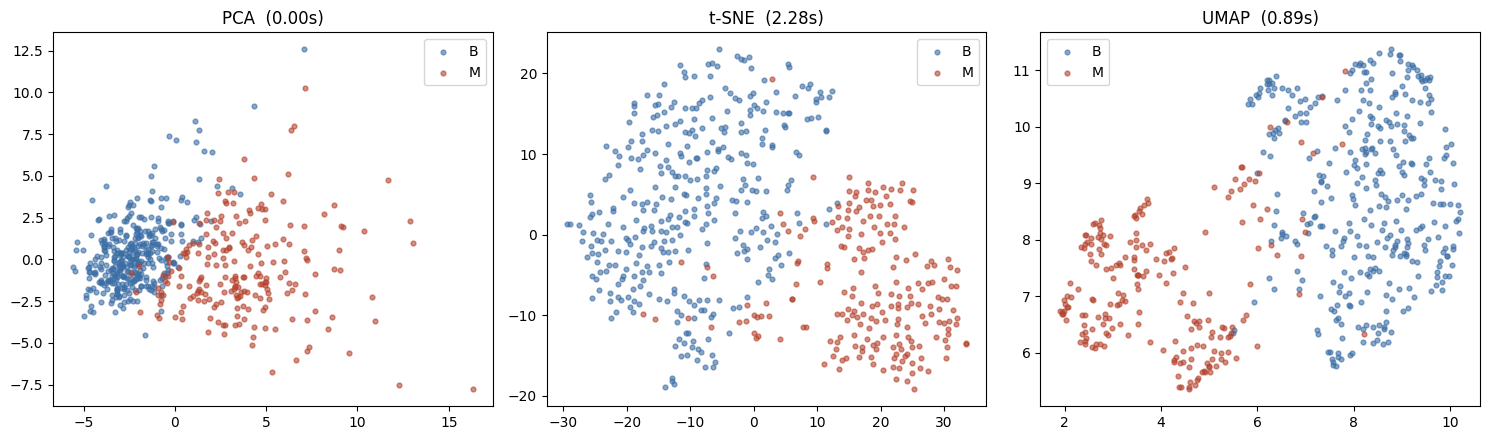

Runtime on 569 patients x 30 features:
  PCA:   0.001s
  t-SNE: 2.283s
  UMAP:  0.894s


In [ ]:
import time

results = {}
t0 = time.time(); results["PCA"] = PCA(n_components=2, random_state=0).fit_transform(X_scaled); t_pca = time.time() - t0
t0 = time.time(); results["t-SNE"] = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_scaled); t_tsne = time.time() - t0
t0 = time.time(); results["UMAP"] = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_scaled); t_umap = time.time() - t0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, emb), t in zip(axes, results.items(), [t_pca, t_tsne, t_umap]):
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.6, color=color, label=label)
    ax.set_title(f"{name}  ({t:.2f}s)")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Runtime on {len(X_scaled)} patients x {X_scaled.shape[1]} features:")
print(f"  PCA:   {t_pca:.3f}s")
print(f"  t-SNE: {t_tsne:.3f}s")
print(f"  UMAP:  {t_umap:.3f}s")

## 18. Real-World Applications  *(Slides 82–84)*

| Domain | Typical pipeline | Use |
|---|---|---|
| Image / Computer Vision | Image features -> PCA/t-SNE/UMAP -> 2D embedding | Spot natural groups, find similar/unusual images, explore CNN embeddings |
| Text & Documents | Document vectors -> UMAP | Discover topics, find unusual documents |
| **Genomics & Biological Data** | Gene expression -> PCA -> t-SNE/UMAP | Identify cell populations, detect unusual samples, visualize biological states |
| ML Model Latent Spaces | 512-D embedding -> PCA/t-SNE/UMAP -> 2D | Class separation, clusters, outliers, misclassifications |

**Why this dataset fits perfectly:** our breast cancer dataset **is** exactly the
"Genomics & Biological Data" row — 30 measured biological variables per patient, reduced
to 2D throughout this notebook to visually separate malignant vs. benign cases, exactly
as the lecture describes for gene-expression data.

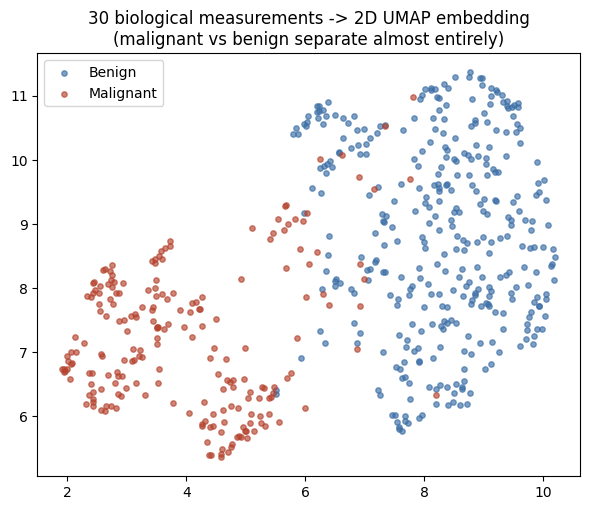

In [ ]:
# Final side-by-side: does the 2D embedding actually help distinguish diagnosis outcome?
fig, ax = plt.subplots(figsize=(7, 5.5))
for label, color, name in [("B", "#3b6ea5", "Benign"), ("M", "#b5432e", "Malignant")]:
    mask = y == label
    ax.scatter(results["UMAP"][mask, 0], results["UMAP"][mask, 1], s=15, alpha=0.65, color=color, label=name)
ax.set_title("30 biological measurements -> 2D UMAP embedding\n(malignant vs benign separate almost entirely)")
ax.legend()
plt.show()

## Summary: Technique -> When to Use It

| Technique | Solves | Use it when... |
|---|---|---|
| Correlogram | Spotting redundant variables | Before any reduction, to see which features are already correlated |
| PCA | Linear compression + visualization | You need a fast, interpretable, reproducible 2D/3D summary |
| Scree / cumulative variance plot | Choosing k | You need to justify how many components to keep |
| t-SNE | Revealing local clusters | Local neighborhood structure matters more than global distances |
| UMAP | Fast local + global structure | You need both cluster shape AND rough global layout, at scale |

**Core principle:** dimensionality reduction turns "we cannot visualize p=30 dimensions"
into "we can visualize the structure that actually matters" — without deleting
information, by deriving new axes/embeddings that concentrate it.